# Classification

The main objective of this assignment is to train binary classification models to predict whether a person earns more than $50,000 per year.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Task 1

# Data Exploration

In [61]:
income_path = Path("income.csv")
income_raw = pd.read_csv(income_path)
income = income_raw.copy()

print("Dataset shape:", income.shape)
display(income.head())

Dataset shape: (9000, 10)


,age,workclass,education,marital status,occupation,workinghours,sex,ability to speak english,gave birth this year,income
0,52,self employed,16,Widowed,Transport,50,Male,NaN,NaN,high
1,60,private,20,Divorced,Healthcare/Medical Services,30,Female,NaN,NaN,low
2,64,private,21,Divorced,Management/Business,40,Male,NaN,NaN,low
3,64,private,17,Husband,Transport,40,Male,NaN,NaN,low
4,31,private,15,Husband,Transport,40,Male,NaN,NaN,low


In [62]:
print("Data types:")
print(income.dtypes)

print("\nNull values per column:")
print(income.isnull().sum())

print("\nUnique values per column:")
print(income.nunique())

Data types:
age                           int64
workclass                    object
education                     int64
marital status               object
occupation                   object
workinghours                  int64
sex                          object
ability to speak english    float64
gave birth this year         object
income                       object
dtype: object

Null values per column:
age                            0
workclass                      0
education                      0
marital status                 0
occupation                     0
workinghours                   0
sex                            0
ability to speak english    8597
gave birth this year        7058
income                         0
dtype: int64

Unique values per column:
age                         73
workclass                    4
education                   23
marital status               6
occupation                  18
workinghours                83
sex                          2
ab

In [63]:
# Look at categorical columns individually to spot unusual values
categorical_cols = income.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(income[col].value_counts(dropna=False))


workclass
workclass
private          6644
governmental     1415
self employed     917
no paid work       24
Name: count, dtype: int64

marital status
marital status
Husband          3588
Never married    2388
Wife             1571
Divorced         1105
Widowed           188
Separated         160
Name: count, dtype: int64

occupation
occupation
Management/Business                  1060
Service/Hospitality                   975
Sales                                 881
Office/Administrative Support         861
Production/Assembly                   838
Transport                             832
Healthcare/Medical Services           693
Construction/Extraction               616
Education                             506
Science, Engineering, Technology      500
Repair/Maintenance                    461
Protective Services                   204
Counseling/Mental Health Services     153
Finance/Accounting                    143
Entertainment                         108
Legal Services         

In [64]:
print("Income distribution by sex (proportions):")
display(pd.crosstab(income["sex"], income["income"], normalize='index')) # normalize='index' each row sums to 1

print("\nIncome distribution by occupation (proportions):")
display(pd.crosstab(income["occupation"], income["income"], normalize='index'))

Income distribution by sex (proportions):


income,high,low
sex,,
Female,0.204333,0.795667
Male,0.411000,0.589000



Income distribution by occupation (proportions):


income,high,low
occupation,,
Construction/Extraction,0.241883,0.758117
Counseling/Mental Health Services,0.405229,0.594771
Education,0.339921,0.660079
Entertainment,0.314815,0.685185
"Farming, Fishing, Forestry",0.196721,0.803279
Finance/Accounting,0.636364,0.363636
Healthcare/Medical Services,0.372294,0.627706
Legal Services,0.703704,0.296296
Management/Business,0.629245,0.370755


### Suspicious columns

Columns that need special attention:
- `ability to speak english`.
- `gave birth this year`.

In [65]:
# Check if any males have a 'Yes' for gave birth this year (shouldn't be possible)
males_gave_birth = income[
    (income["sex"] == "Male") &
    (income["gave birth this year"] == "Yes")
]
print("Males with 'Yes' for gave birth:", males_gave_birth.shape[0])

# Check how many males have NaN (not applicable)
males_nan_birth = income[
    (income["sex"] == "Male") &
    (income["gave birth this year"].isna())
]
print("Males with NaN for gave birth:", males_nan_birth.shape[0])

# Check females with NaN
females_nan_birth = income[
    (income["sex"] == "Female") &
    (income["gave birth this year"].isna())
]
print("Females with NaN for gave birth:", females_nan_birth.shape[0])

Males with 'Yes' for gave birth: 0
Males with NaN for gave birth: 6000
Females with NaN for gave birth: 1058


## Preprocessing

In [66]:
# Encode the target variable (low:0, high:1)
income["income"] = income["income"].map({"low": 0, "high": 1})

print("Target distribution:")
print(income["income"].value_counts())

Target distribution:
income
0    5921
1    3079
Name: count, dtype: int64


Before splitting the data, we check class balance. Since the target is imbalanced, we use `stratify=y` so train and test keep the same low/high income proportions.


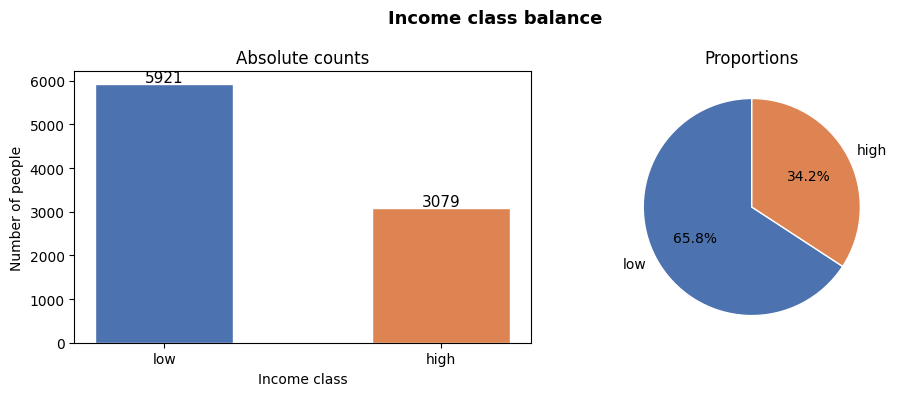

In [67]:
class_counts = income['income'].map({0: 'low', 1: 'high'}).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(class_counts.items()):
    axes[0].text(i, val + 50, str(val), ha='center', fontsize=11)
axes[0].set_title('Absolute counts')
axes[0].set_xlabel('Income class')
axes[0].set_ylabel('Number of people')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proportions')

fig.suptitle('Income class balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The columns with missing values are visualized, as well as the number of affected rows. This helps explain how the missing values are filled in the next cell.

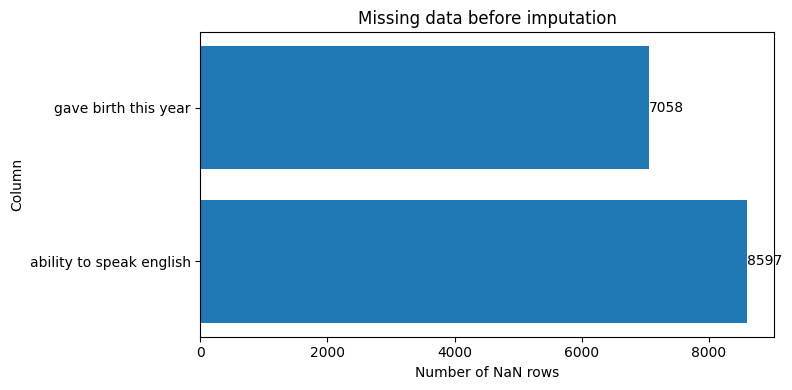

In [68]:
missing_cols = income.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

plt.figure(figsize=(8, 4))

plt.barh(missing_cols.index, missing_cols.values)

for i, val in enumerate(missing_cols.values):
    plt.text(val, i, str(val), va="center", fontsize=10)

plt.title("Missing data before imputation")
plt.xlabel("Number of NaN rows")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

In [69]:
# Handle missing values
income["ability to speak english"] = income["ability to speak english"].fillna(0) # NaN to 0
income["gave birth this year"] = income["gave birth this year"].fillna("Not applicable") # NaN to "Not applicable"

print("Remaining nulls:")
print(income[["ability to speak english", "gave birth this year"]].isnull().sum())

Remaining nulls:
ability to speak english    0
gave birth this year        0
dtype: int64


In [70]:
# Numerical: values represent quantities 
numeric_features = [
    "age",
    "education",
    "workinghours",
    "ability to speak english"
]

# Categorical: text values that don't have a natural order
categorical_features = [
    "workclass",
    "marital status",
    "occupation",
    "sex",
    "gave birth this year"
]

# Preprocessor:
# StandardScaler normalizes numerical features 
# OneHotEncoder converts categorical text into binary columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Separate clone used for model selection and validation experiments
preprocessor_selection = clone(preprocessor)


Before scaling the data, we compare the numeric features for low- and high-income people. Features that look very different between the two groups are probably more useful for classification.

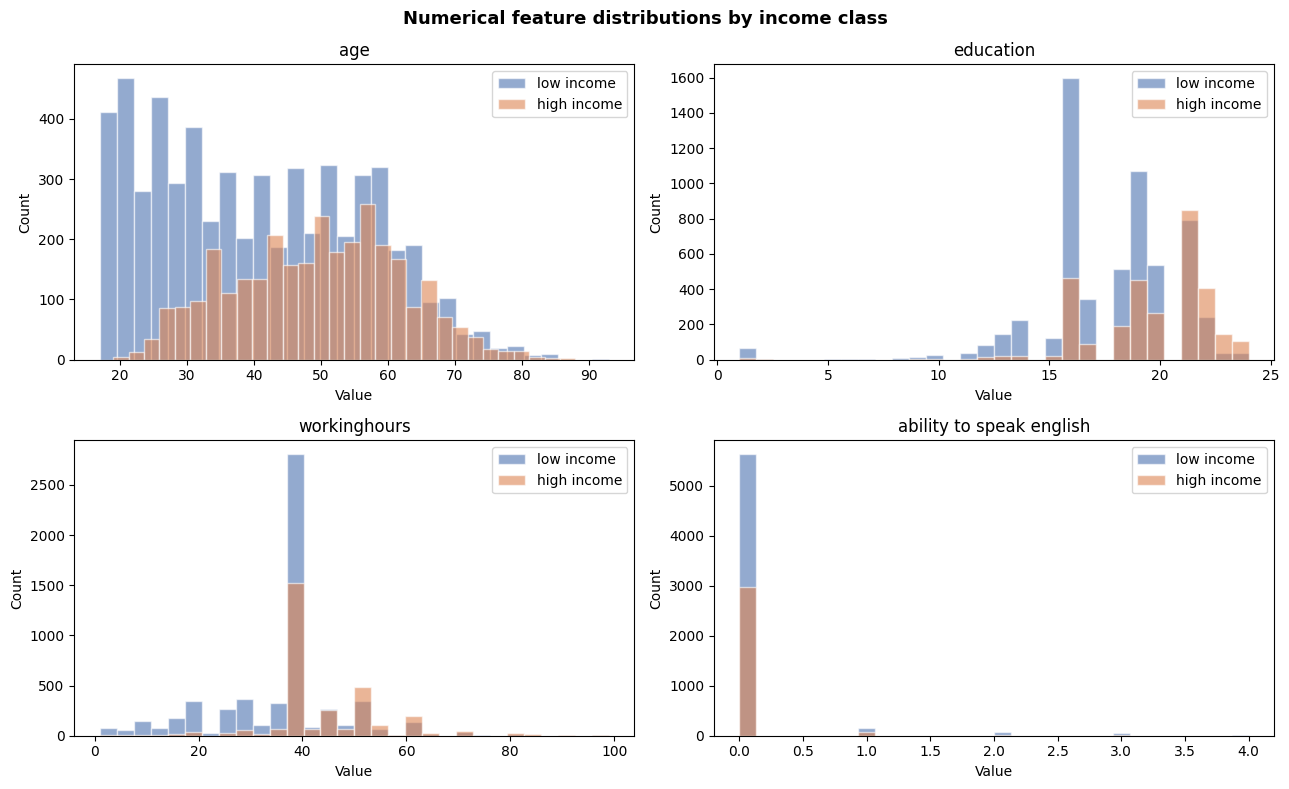

In [71]:
numeric_features_plot = ['age', 'education', 'workinghours', 'ability to speak english']
palette = {0: '#4C72B0', 1: '#DD8452'}
labels  = {0: 'low income', 1: 'high income'}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features_plot):
    for cls in [0, 1]:
        subset = income[income['income'] == cls][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6,
                     color=palette[cls], label=labels[cls], edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

fig.suptitle('Numerical feature distributions by income class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

For the main categorical columns, we plot the high-income rate for each category. The red dashed line shows the overall average. This makes it easy to see which categories are above or below the baseline.

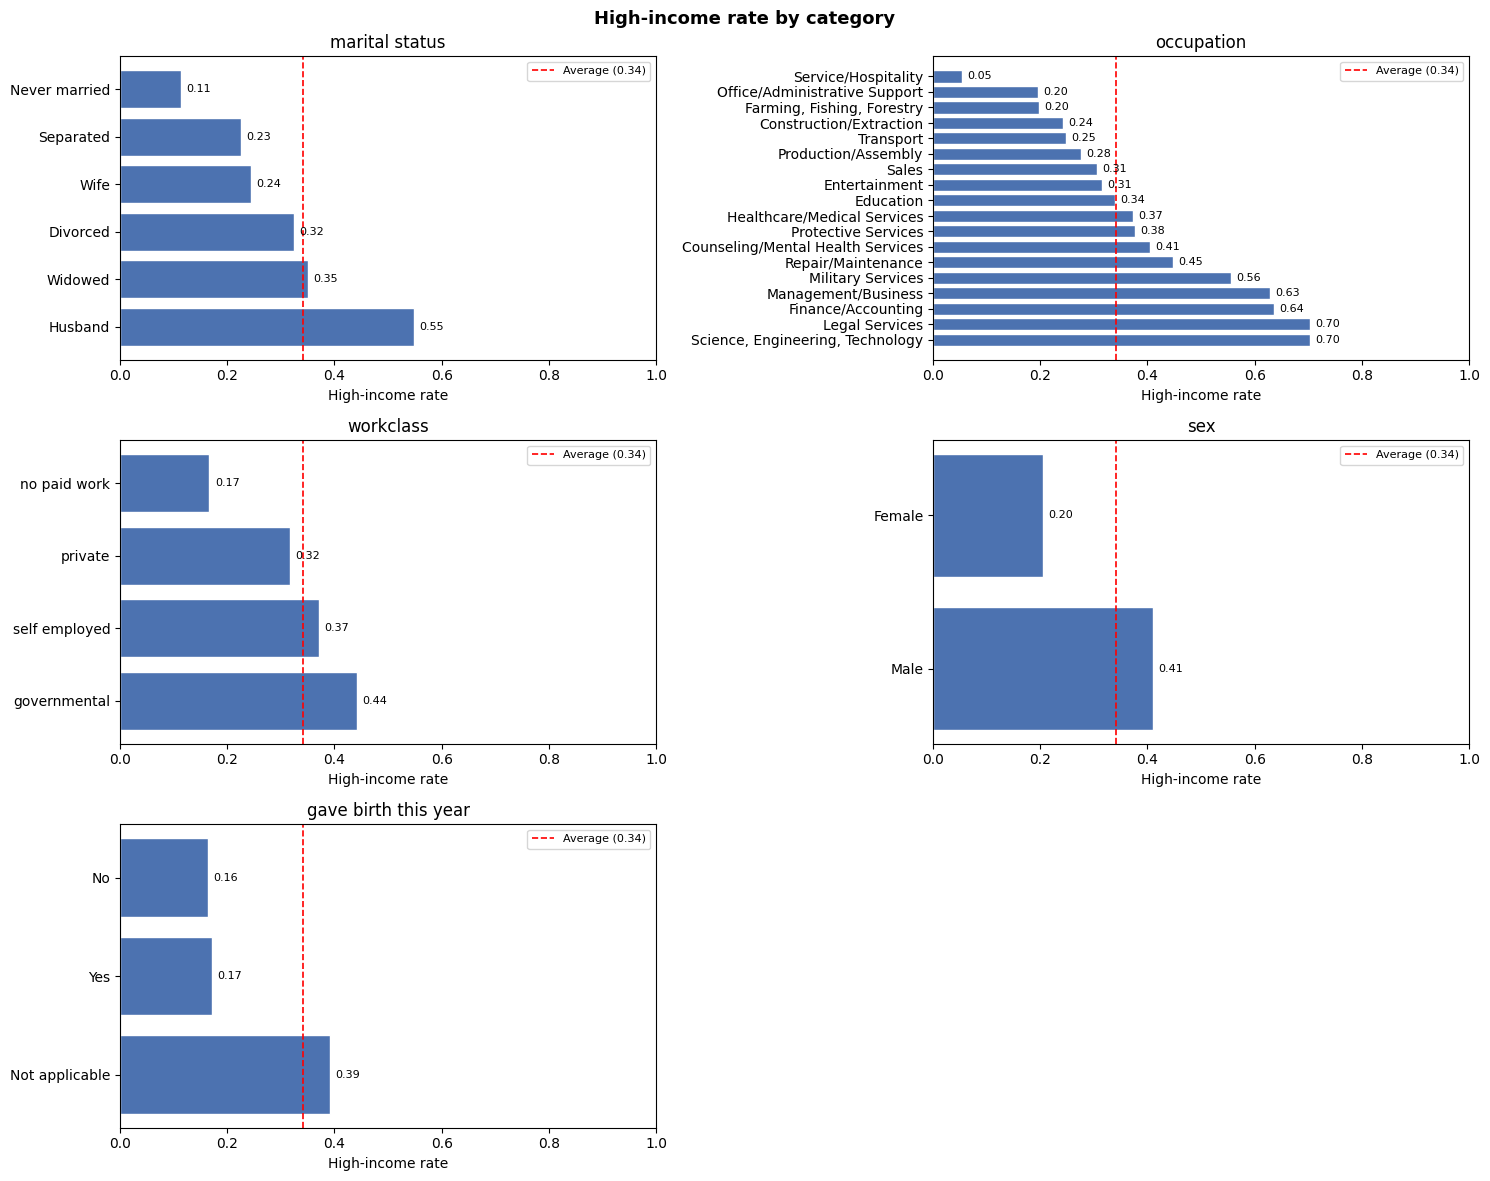

In [72]:
cat_cols_to_plot = ['marital status', 'occupation', 'workclass', 'sex', 'gave birth this year']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
overall_mean = income['income'].mean()

for i, col in enumerate(cat_cols_to_plot):
    rate = income.groupby(col)['income'].mean().sort_values(ascending=False)
    bars = axes[i].barh(rate.index, rate.values, color='#4C72B0', edgecolor='white')
    axes[i].axvline(overall_mean, color='red', linestyle='--', linewidth=1.2,
                    label=f'Average ({overall_mean:.2f})')
    axes[i].set_xlim(0, 1)
    axes[i].set_xlabel('High-income rate')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, rate.values):
        axes[i].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}', va='center', fontsize=8)

axes[-1].axis('off')

fig.suptitle('High-income rate by category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
# Split the data into X and y
# X = the columns we use to make predictions
# y = the column we want to predict (income)

X = income.drop("income", axis=1)
y = income["income"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9000, 9)
y shape: (9000,)


In [74]:
# Split the data before preprocessing
# First split: keep the test set completely separate for final evaluation only

X_train_full_raw, X_test_raw, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: split the training data into train and validation
# Validation is used for hyperparameter selection

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full_raw,
    y_train_full,
    test_size=0.25,  # 25% of 80% = 20% of the full dataset
    random_state=42,
    stratify=y_train_full
)

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:  ", X_val_raw.shape)
print("X_test_raw: ", X_test_raw.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\ny_val distribution:")
print(y_val.value_counts(normalize=True).round(3))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(3))

print("\nTrain, validation, and test have a similar low/high income proportion.")

X_train_raw: (5400, 9)
X_val_raw:   (1800, 9)
X_test_raw:  (1800, 9)

y_train distribution:
income
0    0.658
1    0.342
Name: proportion, dtype: float64

y_val distribution:
income
0    0.658
1    0.342
Name: proportion, dtype: float64

y_test distribution:
income
0    0.658
1    0.342
Name: proportion, dtype: float64

Train, validation, and test have a similar low/high income proportion.


### Preprocessor fit_transform and transform

In [75]:
# Fit the selection preprocessor only on the training split
X_train = preprocessor_selection.fit_transform(X_train_raw)

# Transform validation and test using the same selection preprocessor
X_val = preprocessor_selection.transform(X_val_raw)
X_test_selection = preprocessor_selection.transform(X_test_raw)

print("X_train processed shape:", X_train.shape)
print("X_val processed shape:  ", X_val.shape)
print("X_test_selection processed shape:", X_test_selection.shape)

feature_names_out = preprocessor_selection.get_feature_names_out()

df_train_processed = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names_out,
    index=X_train_raw.index
)

df_val_processed = pd.DataFrame(
    X_val.toarray(),
    columns=feature_names_out,
    index=X_val_raw.index
)

df_test_selection_processed = pd.DataFrame(
    X_test_selection.toarray(),
    columns=feature_names_out,
    index=X_test_raw.index
)

df_train_processed.head()


X_train processed shape: (5400, 37)
X_val processed shape:   (1800, 37)
X_test_selection processed shape: (1800, 37)


,num__age,num__education,num__workinghours,num__ability to speak english,cat__workclass_governmental,cat__workclass_no paid work,cat__workclass_private,cat__workclass_self employed,cat__marital status_Divorced,cat__marital status_Husband,...,cat__occupation_Repair/Maintenance,cat__occupation_Sales,"cat__occupation_Science, Engineering, Technology",cat__occupation_Service/Hospitality,cat__occupation_Transport,cat__sex_Female,cat__sex_Male,cat__gave birth this year_No,cat__gave birth this year_Not applicable,cat__gave birth this year_Yes
8704,-0.745151,0.222588,0.063553,-0.188913,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3369,-0.161388,-0.694016,0.063553,-0.188913,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4746,-0.550563,0.222588,1.650914,-0.188913,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3787,0.876413,0.833656,0.063553,2.305289,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
725,1.330451,-0.999550,0.857234,-0.188913,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


# Models

## Model 1: Logistic Regression

Logistic Regression is a simple linear model and a good baseline. It predicts the probability of high income using the input features.

It is fast and easy to interpret, but it may miss more complex patterns in the data.

In [76]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [77]:
# Predict the probability of high income for each person
lr_proba = lr_model.predict_proba(X_test_selection)[:, 1]

# Predict the final class: 0 = low income, 1 = high income
lr_pred = lr_model.predict(X_test_selection)


In [78]:
# Evaluate Logistic Regression
lr_train_acc = lr_model.score(X_train, y_train)
lr_test_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print("=== Logistic Regression ===")
print(f"Train Accuracy : {lr_train_acc:.4f}")
print(f"Test Accuracy  : {lr_test_acc:.4f}")
print(f"AUC            : {lr_auc:.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=["low", "high"]))

=== Logistic Regression ===
Train Accuracy : 0.7865
Test Accuracy  : 0.7883
AUC            : 0.8490

              precision    recall  f1-score   support

         low       0.82      0.87      0.84      1184
        high       0.72      0.62      0.67       616

    accuracy                           0.79      1800
   macro avg       0.77      0.75      0.76      1800
weighted avg       0.78      0.79      0.78      1800



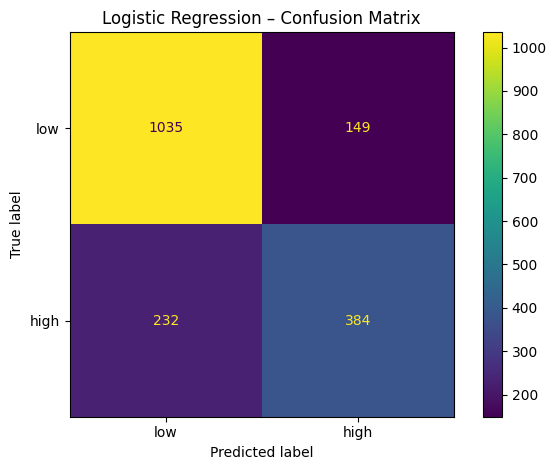

In [79]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=["low", "high"])
plt.title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

### Overfitting check for Logistic Regression

Training accuracy is compared with test accuracy to check whether the model generalizes well to new data.

If the training score is much higher than the test score, the model may be overfitting. This means it learned the training data too closely instead of learning patterns that work on unseen data.

Since Logistic Regression is a simple linear model, it is less likely to overfit. For this reason, the training and test scores are expected to be similar.

In [80]:
gap = lr_train_acc - lr_test_acc
print(f"Train accuracy: {lr_train_acc:.4f}")
print(f"Test accuracy : {lr_test_acc:.4f}")
print(f"Gap           : {gap:.4f}")

Train accuracy: 0.7865
Test accuracy : 0.7883
Gap           : -0.0019


## Model 2: Decision Tree

A Decision Tree splits the data into smaller groups based on feature values.

It is easy to interpret because its decisions can be visualized as a tree. However, if the tree grows too deep, it can overfit by learning the training data too closely instead of general patterns.

In [81]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test_selection)
dt_proba = dt_model.predict_proba(X_test_selection)[:, 1]

dt_train_acc = dt_model.score(X_train, y_train)
dt_test_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_proba)

print("=== Decision Tree (no depth limit) ===")
print(f"Train Accuracy : {dt_train_acc:.4f}")
print(f"Test Accuracy  : {dt_test_acc:.4f}")
print(f"AUC            : {dt_auc:.4f}")
print()
print(classification_report(y_test, dt_pred, target_names=["low", "high"]))


=== Decision Tree (no depth limit) ===
Train Accuracy : 0.9894
Test Accuracy  : 0.7283
AUC            : 0.7012

              precision    recall  f1-score   support

         low       0.79      0.79      0.79      1184
        high       0.60      0.60      0.60       616

    accuracy                           0.73      1800
   macro avg       0.70      0.70      0.70      1800
weighted avg       0.73      0.73      0.73      1800



### Overfitting check for Decision Tree

A Decision Tree with no depth limit can grow until it fits the training data almost perfectly.

This often leads to overfitting, because the model memorizes specific training examples instead of learning general patterns. As a result, the training accuracy can be very high, while the test accuracy is usually lower.

_Note: A large gap (e.g. > 0.10) is a strong sign of overfitting._

In [82]:
gap_dt = dt_train_acc - dt_test_acc
print(f"Train accuracy: {dt_train_acc:.4f}")
print(f"Test accuracy : {dt_test_acc:.4f}")
print(f"Gap           : {gap_dt:.4f}")

Train accuracy: 0.9894
Test accuracy : 0.7283
Gap           : 0.2611


### Reducing overfitting in the Decision Tree

To make the Decision Tree less likely to overfit, two limits are added:

`max_depth=12` limits how deep the tree can grow. A smaller tree is simpler and less likely to memorize the training data.

`min_samples_leaf=20` requires each final leaf to have at least 20 samples. This prevents the model from creating very small leaves that only fit a few specific examples.

In [83]:
dt_experiments = [
    {"max_depth": None, "min_samples_leaf": 1},
    {"max_depth": 4, "min_samples_leaf": 5},
    {"max_depth": 6, "min_samples_leaf": 5},
    {"max_depth": 8, "min_samples_leaf": 10},
    {"max_depth": 10, "min_samples_leaf": 10},
    {"max_depth": 12, "min_samples_leaf": 20},
]

dt_results = []

for params in dt_experiments:
    dt_model = DecisionTreeClassifier(
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42
    )

    dt_model.fit(X_train, y_train)

    train_acc = dt_model.score(X_train, y_train)

    val_pred = dt_model.predict(X_val)
    val_proba = dt_model.predict_proba(X_val)[:, 1]

    val_acc = accuracy_score(y_val, val_pred)
    val_auc = roc_auc_score(y_val, val_proba)
    gap = train_acc - val_acc

    dt_results.append({
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc,
        "train_validation_gap": gap,
        "validation_auc": val_auc
    })

dt_results_df = pd.DataFrame(dt_results)

dt_results_df.sort_values(
    by=["validation_auc", "validation_accuracy", "train_validation_gap"],
    ascending=[False, False, True]
)

,max_depth,min_samples_leaf,train_accuracy,validation_accuracy,train_validation_gap,validation_auc
5,12.0,20,0.799815,0.767778,0.032037,0.830631
3,8.0,10,0.797778,0.766667,0.031111,0.821797
2,6.0,5,0.779630,0.756111,0.023519,0.820039
4,10.0,10,0.809074,0.759444,0.049630,0.815754
1,4.0,5,0.765556,0.753889,0.011667,0.814030
0,NaN,1,0.989444,0.728889,0.260556,0.703256


The configuration max_depth=12 and min_samples_leaf=20 was selected using the validation set. It achieved the best validation-based trade-off among the regularized Decision Tree models, while keeping the train-validation gap small. After selecting this configuration, the model was retrained on the full training data and evaluated once on the test set.

In [84]:
dt_tuned = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=20,
    random_state=42
)

# Final preprocessing is fitted on train + validation only,
# after model and hyperparameter selection are complete.
preprocessor_final = clone(preprocessor)

X_train_full_processed = preprocessor_final.fit_transform(X_train_full_raw)
X_test_full_processed = preprocessor_final.transform(X_test_raw)

feature_names_full = preprocessor_final.get_feature_names_out()

dt_tuned.fit(X_train_full_processed, y_train_full)
dt_tuned_pred = dt_tuned.predict(X_test_full_processed)
dt_tuned_proba = dt_tuned.predict_proba(X_test_full_processed)[:, 1]

dt_tuned_train_acc = dt_tuned.score(X_train_full_processed, y_train_full)
dt_tuned_test_acc = accuracy_score(y_test, dt_tuned_pred)
dt_tuned_auc = roc_auc_score(y_test, dt_tuned_proba)

print("=== Decision Tree (tuned, final test evaluation) ===")
print(f"Train Accuracy : {dt_tuned_train_acc:.4f}")
print(f"Test Accuracy  : {dt_tuned_test_acc:.4f}")
print(f"Gap            : {dt_tuned_train_acc - dt_tuned_test_acc:.4f}")
print(f"AUC            : {dt_tuned_auc:.4f}")
print()
print(classification_report(y_test, dt_tuned_pred, target_names=["low", "high"]))


=== Decision Tree (tuned, final test evaluation) ===
Train Accuracy : 0.8033
Test Accuracy  : 0.7706
Gap            : 0.0328
AUC            : 0.8306

              precision    recall  f1-score   support

         low       0.80      0.86      0.83      1184
        high       0.69      0.60      0.64       616

    accuracy                           0.77      1800
   macro avg       0.75      0.73      0.74      1800
weighted avg       0.77      0.77      0.77      1800



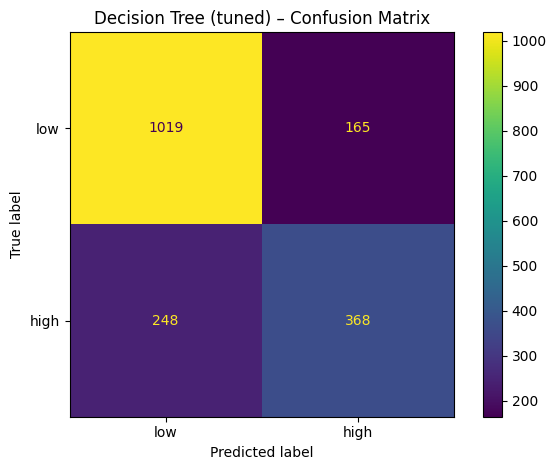

In [85]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_tuned_pred, display_labels=["low", "high"])
plt.title("Decision Tree (tuned) – Confusion Matrix")
plt.tight_layout()
plt.show()

## Model 3: Random Forest

Random Forest combines many Decision Trees to make a stronger model.

Each tree learns from a slightly different part of the data, and the final prediction is based on the trees voting together.

This usually makes Random Forest more stable than a single Decision Tree. It can still overfit, but much less than a tree with no limits.

In [86]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test_selection)
rf_proba = rf_model.predict_proba(X_test_selection)[:, 1]

rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print("=== Random Forest (default) ===")
print(f"Train Accuracy : {rf_train_acc:.4f}")
print(f"Test Accuracy  : {rf_test_acc:.4f}")
print(f"AUC            : {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=["low", "high"]))


=== Random Forest (default) ===
Train Accuracy : 0.9893
Test Accuracy  : 0.7772
AUC            : 0.8330

              precision    recall  f1-score   support

         low       0.82      0.85      0.83      1184
        high       0.69      0.64      0.66       616

    accuracy                           0.78      1800
   macro avg       0.75      0.74      0.75      1800
weighted avg       0.77      0.78      0.78      1800



### Overfitting check for Random Forest

A Random Forest with no depth limit can still overfit, so the training accuracy may be very high.

But because it uses many trees instead of just one, it usually handles new data better than a single Decision Tree.

In [87]:
gap_rf = rf_train_acc - rf_test_acc
print(f"Train accuracy: {rf_train_acc:.4f}")
print(f"Test accuracy : {rf_test_acc:.4f}")
print(f"Gap           : {gap_rf:.4f}")

Train accuracy: 0.9893
Test accuracy : 0.7772
Gap           : 0.2120


### Reducing overfitting in Random Forest

The same idea used for the Decision Tree is applied here.

Tree depth is limited so the trees do not become too complex. A minimum number of samples per leaf is also required, so the model does not create very small groups based on only a few examples.

These limits help the Random Forest learn more general patterns and reduce overfitting.

In [88]:
rf_experiments = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 6, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 8, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 10, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 12, "min_samples_leaf": 10},
    {"n_estimators": 100, "max_depth": 14, "min_samples_leaf": 10},
    {"n_estimators": 100, "max_depth": 16, "min_samples_leaf": 20},
]

rf_results = []

for params in rf_experiments:
    rf_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    train_acc = rf_model.score(X_train, y_train)

    val_pred = rf_model.predict(X_val)
    val_proba = rf_model.predict_proba(X_val)[:, 1]

    val_acc = accuracy_score(y_val, val_pred)
    val_auc = roc_auc_score(y_val, val_proba)
    gap = train_acc - val_acc

    rf_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc,
        "train_validation_gap": gap,
        "validation_auc": val_auc
    })

rf_results_df = pd.DataFrame(rf_results)

rf_results_df.sort_values(
    by=["validation_auc", "validation_accuracy", "train_validation_gap"],
    ascending=[False, False, True]
)

,n_estimators,max_depth,min_samples_leaf,train_accuracy,validation_accuracy,train_validation_gap,validation_auc
5,100,14.0,10,0.805556,0.788333,0.017222,0.864519
3,100,10.0,5,0.809259,0.790000,0.019259,0.863643
4,100,12.0,10,0.803704,0.787778,0.015926,0.863115
6,100,16.0,20,0.795000,0.786111,0.008889,0.861314
2,100,8.0,5,0.800370,0.785000,0.015370,0.859723
1,100,6.0,5,0.782222,0.776111,0.006111,0.851986
0,100,NaN,1,0.989259,0.762778,0.226481,0.827065


Although max_depth=10 and min_samples_leaf=5 obtained the highest validation accuracy, the difference with max_depth=14 and min_samples_leaf=10 was very small. I selected max_depth=14 and min_samples_leaf=10 because it gave strong validation performance while keeping the train-validation gap small. After selecting this configuration, the model was retrained on the full training data and evaluated once on the test set.

In [89]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=14,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

# Train final tuned Random Forest on train + validation data
rf_tuned.fit(X_train_full_processed, y_train_full)

rf_tuned_pred = rf_tuned.predict(X_test_full_processed)
rf_tuned_proba = rf_tuned.predict_proba(X_test_full_processed)[:, 1]

rf_tuned_train_acc = rf_tuned.score(X_train_full_processed, y_train_full)
rf_tuned_test_acc = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_proba)

print("=== Random Forest (tuned, final test evaluation) ===")
print(f"Train Accuracy : {rf_tuned_train_acc:.4f}")
print(f"Test Accuracy  : {rf_tuned_test_acc:.4f}")
print(f"Gap            : {rf_tuned_train_acc - rf_tuned_test_acc:.4f}")
print(f"AUC            : {rf_tuned_auc:.4f}")
print()
print(classification_report(y_test, rf_tuned_pred, target_names=["low", "high"]))

=== Random Forest (tuned, final test evaluation) ===
Train Accuracy : 0.8060
Test Accuracy  : 0.7794
Gap            : 0.0265
AUC            : 0.8502

              precision    recall  f1-score   support

         low       0.81      0.88      0.84      1184
        high       0.71      0.59      0.65       616

    accuracy                           0.78      1800
   macro avg       0.76      0.73      0.74      1800
weighted avg       0.77      0.78      0.77      1800



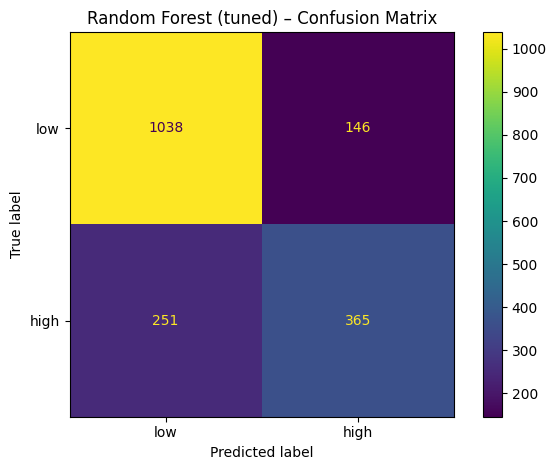

In [90]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_tuned_pred, display_labels=["low", "high"])
plt.title("Random Forest (tuned) – Confusion Matrix")
plt.tight_layout()
plt.show()

## Confusion Matrices

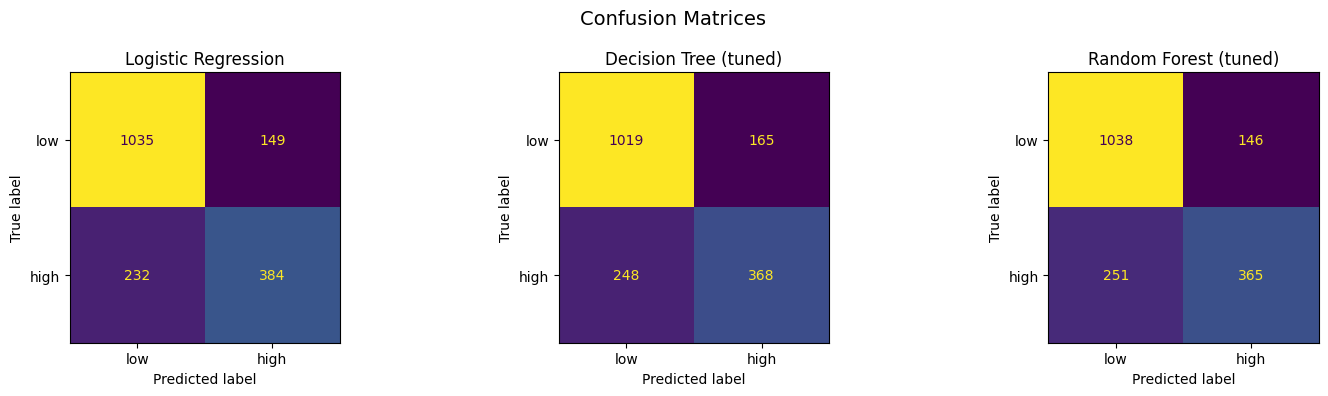

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["low", "high"],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_tuned_pred,
    display_labels=["low", "high"],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree (tuned)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_tuned_pred,
    display_labels=["low", "high"],
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("Random Forest (tuned)")

fig.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

## Feature Importance

In [92]:
# Random Forest importance shows which features were most useful for the trees.
# Higher values mean the feature helped more when making predictions.
rf_importance = pd.DataFrame({
    "feature": feature_names_full,
    "importance": rf_tuned.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 10 features – Random Forest (tuned):")
display(rf_importance.head(10))


Top 10 features – Random Forest (tuned):


,feature,importance
1,num__education,0.221765
0,num__age,0.154418
2,num__workinghours,0.139337
9,cat__marital status_Husband,0.122604
10,cat__marital status_Never married,0.071061
22,cat__occupation_Management/Business,0.047831
30,cat__occupation_Service/Hospitality,0.039440
29,"cat__occupation_Science, Engineering, Technology",0.033391
32,cat__sex_Female,0.027646
33,cat__sex_Male,0.020914


In [93]:
# Decision Tree same importance metric
dt_importance = pd.DataFrame({
    "feature": feature_names_full,
    "importance": dt_tuned.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 10 features – Decision Tree (tuned):")
display(dt_importance.head(10))


Top 10 features – Decision Tree (tuned):


,feature,importance
9,cat__marital status_Husband,0.307090
1,num__education,0.272855
0,num__age,0.158258
2,num__workinghours,0.143156
22,cat__occupation_Management/Business,0.024160
29,"cat__occupation_Science, Engineering, Technology",0.018982
16,cat__occupation_Education,0.011596
30,cat__occupation_Service/Hospitality,0.009982
13,cat__marital status_Wife,0.007374
20,cat__occupation_Healthcare/Medical Services,0.006507


In [94]:
# Logistic Regression coefficients show each feature's effect
# Positive = high income, negative = low income

lr_importance = pd.DataFrame({
    "feature": feature_names_out,
    "coefficient": lr_model.coef_[0]
})

lr_importance["absolute_importance"] = lr_importance["coefficient"].abs()
lr_importance = lr_importance.sort_values(by="absolute_importance", ascending=False)

print("Top 10 features for Logistic Regression:")
display(lr_importance.head(10))


Top 10 features for Logistic Regression:


,feature,coefficient,absolute_importance
30,cat__occupation_Service/Hospitality,-1.647277,1.647277
29,"cat__occupation_Science, Engineering, Technology",1.256260,1.256260
5,cat__workclass_no paid work,-0.954225,0.954225
19,cat__occupation_Finance/Accounting,0.823181,0.823181
22,cat__occupation_Management/Business,0.736897,0.736897
1,num__education,0.708925,0.708925
2,num__workinghours,0.679914,0.679914
10,cat__marital status_Never married,-0.660134,0.660134
14,cat__occupation_Construction/Extraction,-0.630909,0.630909
11,cat__marital status_Separated,-0.598565,0.598565


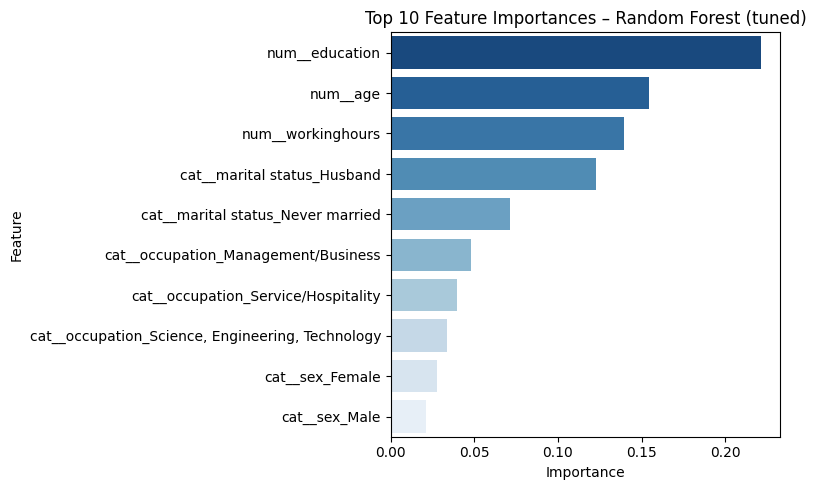

In [95]:
top_features = rf_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_features, x="importance", y="feature", palette="Blues_r")
plt.title("Top 10 Feature Importances – Random Forest (tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Selection Experiment

In [96]:
# Treated as part of the learning process.
# Top 10 features are selected using only the training split,
# not the final test set and not a model already trained on train + validation.

# Train a Random Forest on the training split only
rf_for_selection = RandomForestClassifier(
    n_estimators=100,
    max_depth=14,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_for_selection.fit(X_train, y_train)

rf_selection_importance = pd.DataFrame({
    "feature": feature_names_out,
    "importance": rf_for_selection.feature_importances_
}).sort_values(by="importance", ascending=False)

top_10_features = rf_selection_importance.head(10)["feature"].values

print("Top 10 features selected using the training split only:")
display(rf_selection_importance.head(10))

# Create processed DataFrames for train and validation.
# X_train and X_val come from the preprocessor fitted on the training split.
df_train_processed = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names_out,
    index=X_train_raw.index
)

df_val_processed = pd.DataFrame(
    X_val.toarray(),
    columns=feature_names_out,
    index=X_val_raw.index
)

X_train_sel = df_train_processed[top_10_features]
X_val_sel = df_val_processed[top_10_features]

# Validate the selected-feature model on the validation set
rf_selected_val = RandomForestClassifier(
    n_estimators=100,
    max_depth=14,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_selected_val.fit(X_train_sel, y_train)

rf_selected_val_pred = rf_selected_val.predict(X_val_sel)
rf_selected_val_proba = rf_selected_val.predict_proba(X_val_sel)[:, 1]

rf_selected_val_train_acc = rf_selected_val.score(X_train_sel, y_train)
rf_selected_val_acc = accuracy_score(y_val, rf_selected_val_pred)
rf_selected_val_auc = roc_auc_score(y_val, rf_selected_val_proba)

print("=== Random Forest (top 10 features, validation evaluation) ===")
print(f"Train Accuracy      : {rf_selected_val_train_acc:.4f}")
print(f"Validation Accuracy : {rf_selected_val_acc:.4f}")
print(f"Gap                 : {rf_selected_val_train_acc - rf_selected_val_acc:.4f}")
print(f"Validation AUC      : {rf_selected_val_auc:.4f}")

# After feature selection, retrain on train + validation
# and evaluate once on the test set using the final preprocessor.
df_train_full_processed = pd.DataFrame(
    X_train_full_processed.toarray(),
    columns=feature_names_full,
    index=X_train_full_raw.index
)

df_test_processed = pd.DataFrame(
    X_test_full_processed.toarray(),
    columns=feature_names_full,
    index=X_test_raw.index
)

X_train_full_sel = df_train_full_processed[top_10_features]
X_test_sel = df_test_processed[top_10_features]

rf_selected = RandomForestClassifier(
    n_estimators=100,
    max_depth=14,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_selected.fit(X_train_full_sel, y_train_full)

rf_sel_pred = rf_selected.predict(X_test_sel)
rf_sel_proba = rf_selected.predict_proba(X_test_sel)[:, 1]

rf_sel_train_acc = rf_selected.score(X_train_full_sel, y_train_full)
rf_sel_test_acc = accuracy_score(y_test, rf_sel_pred)
rf_sel_auc = roc_auc_score(y_test, rf_sel_proba)

print("=== Random Forest (top 10 features, final test evaluation) ===")
print(f"Train Accuracy : {rf_sel_train_acc:.4f}")
print(f"Test Accuracy  : {rf_sel_test_acc:.4f}")
print(f"Gap            : {rf_sel_train_acc - rf_sel_test_acc:.4f}")
print(f"AUC            : {rf_sel_auc:.4f}")
print()
print(classification_report(y_test, rf_sel_pred, target_names=["low", "high"]))

rf_selected_importance = pd.DataFrame({
    "feature": X_train_full_sel.columns,
    "importance": rf_selected.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 10 features – Random Forest (selected top 10 model):")
display(rf_selected_importance)


Top 10 features selected using the training split only:


,feature,importance
1,num__education,0.212811
2,num__workinghours,0.149013
0,num__age,0.148528
9,cat__marital status_Husband,0.126672
10,cat__marital status_Never married,0.070239
22,cat__occupation_Management/Business,0.045786
30,cat__occupation_Service/Hospitality,0.038576
29,"cat__occupation_Science, Engineering, Technology",0.036766
32,cat__sex_Female,0.027008
33,cat__sex_Male,0.021607


=== Random Forest (top 10 features, validation evaluation) ===
Train Accuracy      : 0.8070
Validation Accuracy : 0.7906
Gap                 : 0.0165
Validation AUC      : 0.8574
=== Random Forest (top 10 features, final test evaluation) ===
Train Accuracy : 0.8065
Test Accuracy  : 0.7861
Gap            : 0.0204
AUC            : 0.8480

              precision    recall  f1-score   support

         low       0.81      0.88      0.84      1184
        high       0.72      0.61      0.66       616

    accuracy                           0.79      1800
   macro avg       0.77      0.74      0.75      1800
weighted avg       0.78      0.79      0.78      1800

Top 10 features – Random Forest (selected top 10 model):


,feature,importance
0,num__education,0.264805
2,num__age,0.194175
3,cat__marital status_Husband,0.160643
1,num__workinghours,0.156701
4,cat__marital status_Never married,0.065203
5,cat__occupation_Management/Business,0.046342
8,cat__sex_Female,0.031371
6,cat__occupation_Service/Hospitality,0.030623
7,"cat__occupation_Science, Engineering, Technology",0.029234
9,cat__sex_Male,0.020903


## Final comparison of all models

This table summarizes the main results for each model: training accuracy, test accuracy, and AUC.

A good model should have high test accuracy and AUC, with a small difference between training and test accuracy. This means the model performs well without overfitting.

This table summarizes the modeling process rather than a perfectly controlled final tournament. The baseline models were trained on the initial training split to diagnose overfitting, while the tuned and final models were retrained on train + validation after model selection. Therefore, the results should be interpreted as a comparison of the modeling stages and final selected models, not as a comparison where every model used exactly the same training size.

In [97]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (default)",
        "Decision Tree (tuned)",
        "Random Forest (default)",
        "Random Forest (tuned)",
        "Random Forest (top 10 features)"
    ],
    "Train Accuracy": [
        lr_train_acc,
        dt_train_acc,
        dt_tuned_train_acc,
        rf_train_acc,
        rf_tuned_train_acc,
        rf_sel_train_acc
    ],
    "Test Accuracy": [
        lr_test_acc,
        dt_test_acc,
        dt_tuned_test_acc,
        rf_test_acc,
        rf_tuned_test_acc,
        rf_sel_test_acc
    ],
    "AUC": [
        lr_auc,
        dt_auc,
        dt_tuned_auc,
        rf_auc,
        rf_tuned_auc,
        rf_sel_auc
    ]
})

results["Train-Test Gap"] = (results["Train Accuracy"] - results["Test Accuracy"]).round(4)
results = results.round(4)
display(results)

,Model,Train Accuracy,Test Accuracy,AUC,Train-Test Gap
0,Logistic Regression,0.7865,0.7883,0.8490,-0.0019
1,Decision Tree (default),0.9894,0.7283,0.7012,0.2611
2,Decision Tree (tuned),0.8033,0.7706,0.8306,0.0328
3,Random Forest (default),0.9893,0.7772,0.8330,0.2120
4,Random Forest (tuned),0.8060,0.7794,0.8502,0.0265
5,Random Forest (top 10 features),0.8065,0.7861,0.8480,0.0204


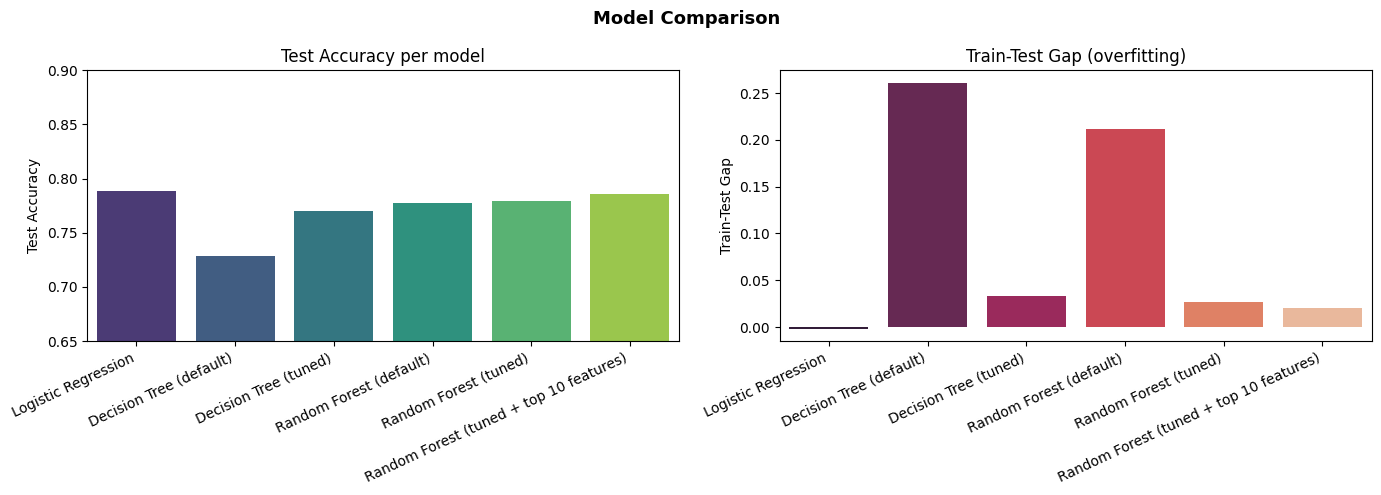

In [98]:
results_main = results.copy().reset_index(drop=True)

results_main["Model"] = results_main["Model"].replace({
    "Random Forest (top 10 features)": "Random Forest (tuned + top 10 features)"
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy
sns.barplot(data=results_main, x="Model", y="Test Accuracy", palette="viridis", ax=axes[0])
axes[0].set_title("Test Accuracy per model")
axes[0].set_ylim(0.65, 0.90)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

for label in axes[0].get_xticklabels():
    label.set_ha("right")

# Train-Test Gap
sns.barplot(data=results_main, x="Model", y="Train-Test Gap", palette="rocket", ax=axes[1])
axes[1].set_title("Train-Test Gap (overfitting)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)

for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

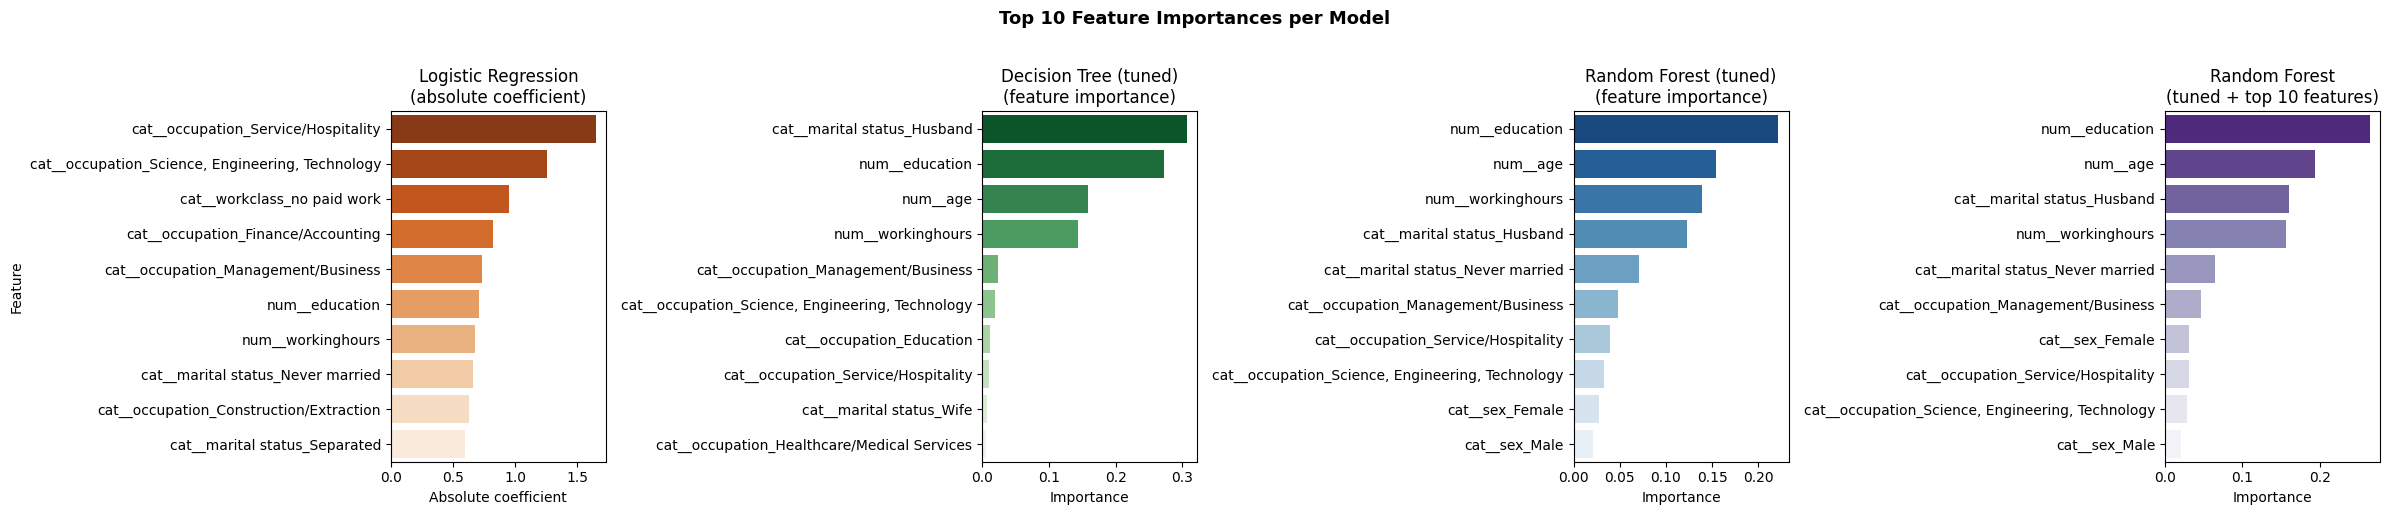

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Logistic Regression
top_lr = lr_importance.head(10)
sns.barplot(data=top_lr, x="absolute_importance", y="feature", palette="Oranges_r", ax=axes[0])
axes[0].set_title("Logistic Regression\n(absolute coefficient)")
axes[0].set_xlabel("Absolute coefficient")
axes[0].set_ylabel("Feature")

# Decision Tree (tuned)
top_dt = dt_importance.head(10)
sns.barplot(data=top_dt, x="importance", y="feature", palette="Greens_r", ax=axes[1])
axes[1].set_title("Decision Tree (tuned)\n(feature importance)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

# Random Forest (tuned)
top_rf = rf_importance.head(10)
sns.barplot(data=top_rf, x="importance", y="feature", palette="Blues_r", ax=axes[2])
axes[2].set_title("Random Forest (tuned)\n(feature importance)")
axes[2].set_xlabel("Importance")
axes[2].set_ylabel("")

# Random Forest (tuned + top 10 features)
top_rf_selected = rf_selected_importance.head(10)
sns.barplot(data=top_rf_selected, x="importance", y="feature", palette="Purples_r", ax=axes[3])
axes[3].set_title("Random Forest\n(tuned + top 10 features)")
axes[3].set_xlabel("Importance")
axes[3].set_ylabel("")

plt.suptitle("Top 10 Feature Importances per Model", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Task 2

## Model Explainability

Random Forest with the top 10 features was selected as the final model.

The Random Forest with the top 10 selected features is chosen as the final model as a practical trade-off. Logistic Regression has slightly higher test accuracy, but the top-10 Random Forest has very similar accuracy and AUC, a small train-test gap, fewer input features, and provides a clear basis for SHAP explanations.

In [100]:
import shap

# Create a SHAP explainer for the final Random Forest model using TreeExplainer for convenience.
explainer = shap.TreeExplainer(rf_selected)

print("Explainer created for:", type(rf_selected).__name__)
print("Model trained on", len(top_10_features), "features:")
print(list(top_10_features))

Explainer created for: RandomForestClassifier
Model trained on 10 features:
['num__education', 'num__workinghours', 'num__age', 'cat__marital status_Husband', 'cat__marital status_Never married', 'cat__occupation_Management/Business', 'cat__occupation_Service/Hospitality', 'cat__occupation_Science, Engineering, Technology', 'cat__sex_Female', 'cat__sex_Male']


## Calculate SHAP values

In [101]:
# Calculate SHAP values for the test set and select the high-income class.

shap_values = explainer.shap_values(X_test_sel)

if isinstance(shap_values, list):
    shap_values_high = shap_values[1]
    base_value_high = explainer.expected_value[1]
else:
    shap_values_high = shap_values[:, :, 1]
    base_value_high = explainer.expected_value[1]

print("shap_values_high shape:", shap_values_high.shape)
print("base_value_high:", round(base_value_high, 4))

shap_values_high shape: (1800, 10)
base_value_high: 0.3431


## Most important features overall (global explanation)

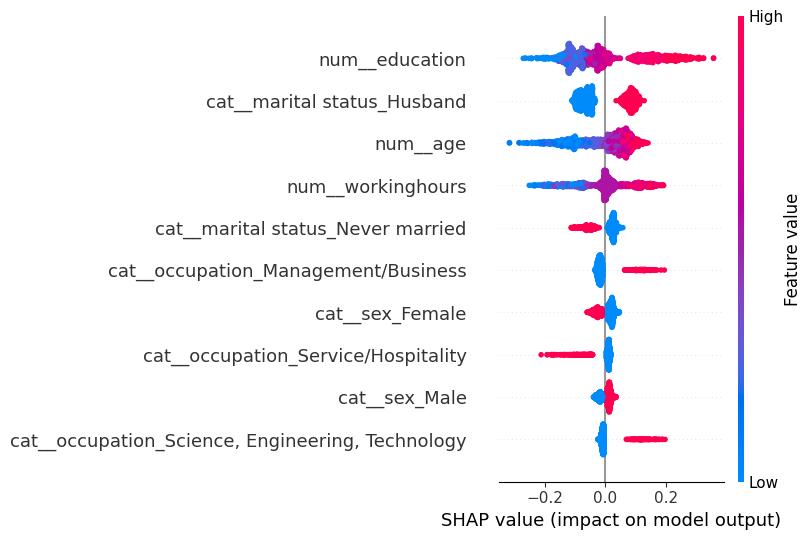

In [102]:
shap.summary_plot(shap_values_high, X_test_sel, max_display=10)

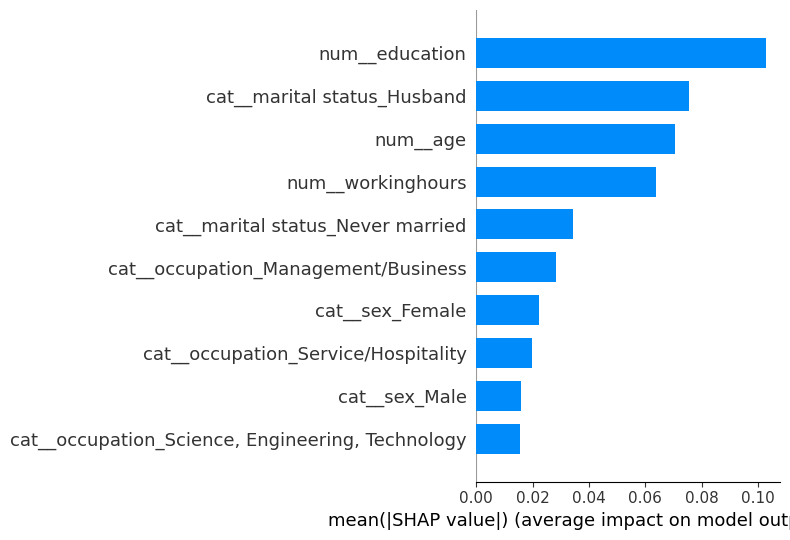

In [103]:
shap.summary_plot(shap_values_high, X_test_sel, plot_type="bar", max_display=10)

## Individual predictions explained (local explanation)

In [104]:
test_predictions = rf_selected.predict(X_test_sel)
test_probas = rf_selected.predict_proba(X_test_sel)[:, 1]

proba_series = pd.Series(test_probas, index=X_test_sel.index)

# Select the most confident high- and low-income predictions for local SHAP explanations.

high_idx_label = proba_series.idxmax()
low_idx_label = proba_series.idxmin()

high_idx = X_test_sel.index.get_loc(high_idx_label)
low_idx = X_test_sel.index.get_loc(low_idx_label)

print(f"Most confident HIGH prediction — row {high_idx_label}")
print(f"  Predicted proba : {test_probas[high_idx]:.3f}")
print(f"  Actual label    : {'high' if y_test.iloc[high_idx] == 1 else 'low'}")
print()
print(f"Most confident LOW prediction — row {low_idx_label}")
print(f"  Predicted proba : {test_probas[low_idx]:.3f}")
print(f"  Actual label    : {'high' if y_test.iloc[low_idx] == 1 else 'low'}")

Most confident HIGH prediction — row 1452
  Predicted proba : 0.964
  Actual label    : high

Most confident LOW prediction — row 7199
  Predicted proba : 0.000
  Actual label    : low


=== Explanation: Person predicted as HIGH income ===


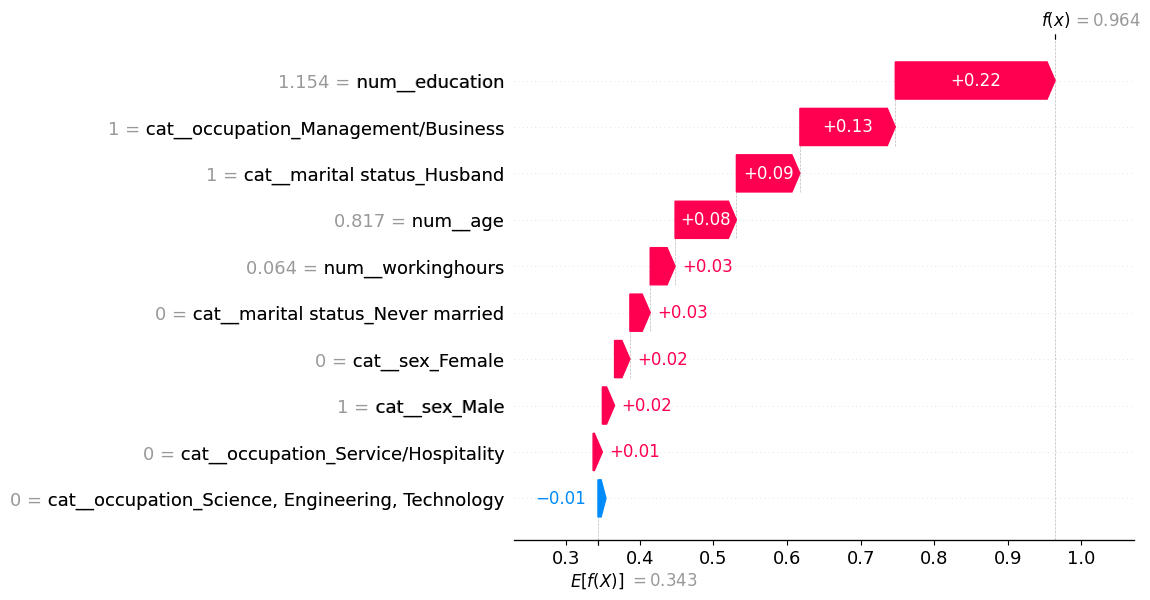

In [105]:
print("=== Explanation: Person predicted as HIGH income ===")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_high[high_idx],
        base_values=base_value_high,
        data=X_test_sel.iloc[high_idx].values,
        feature_names=X_test_sel.columns.tolist()
    )
)

=== Explanation: Person predicted as LOW income ===


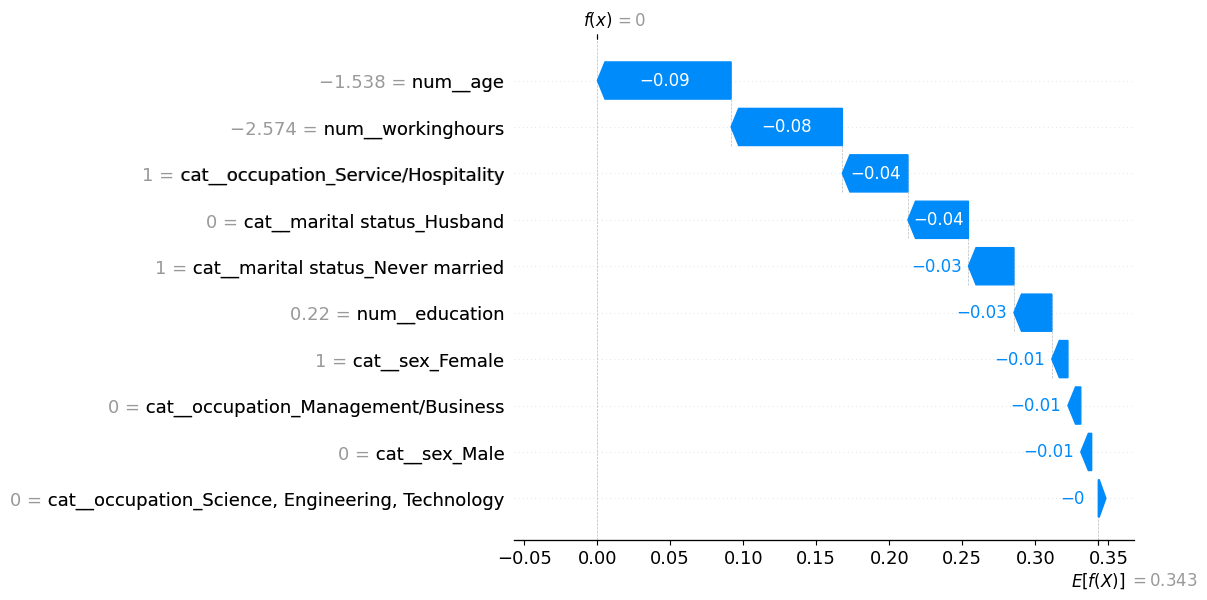

In [106]:
print("=== Explanation: Person predicted as LOW income ===")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_high[low_idx],
        base_values=base_value_high,
        data=X_test_sel.iloc[low_idx].values,
        feature_names=X_test_sel.columns.tolist()
    )
)

# Task 3

# Applying the Model to New Instances

## Load and inspect the new data

In [107]:
test_path = Path("income_test.csv")
income_test_raw = pd.read_csv(test_path)
income_test = income_test_raw.copy()

print("New dataset shape:", income_test.shape)
display(income_test.head())

New dataset shape: (2000, 9)


,age,workclass,education,marital status,occupation,workinghours,sex,ability to speak english,gave birth this year
0,61,private,18,Husband,Sales,45,Male,NaN,NaN
1,62,private,21,Husband,Sales,60,Male,NaN,NaN
2,75,governmental,24,Widowed,Education,56,Female,NaN,NaN
3,20,private,16,Never married,"Farming, Fishing, Forestry",45,Male,NaN,NaN
4,41,private,17,Husband,Production/Assembly,80,Male,NaN,NaN


In [108]:
# Missing values in the new data
print("Null values per column:")
print(income_test.isnull().sum())

Null values per column:
age                            0
workclass                      0
education                      0
marital status                 0
occupation                     0
workinghours                   0
sex                            0
ability to speak english    1895
gave birth this year        1438
dtype: int64


In [109]:
# Same missing value treatment as in training
income_test["ability to speak english"] = income_test["ability to speak english"].fillna(0)
income_test["gave birth this year"]      = income_test["gave birth this year"].fillna("Not applicable")

print("Nulls after filling:", income_test.isnull().sum().sum())

Nulls after filling: 0


In [110]:
# Same preprocessing learned from the final training data (train + validation).
X_new = preprocessor_final.transform(income_test)

# Convert the processed data into a DataFrame.
df_new_processed = pd.DataFrame(
    X_new.toarray(),
    columns=preprocessor_final.get_feature_names_out()
)

# Keep only the same top 10 features used by the selected model.
X_new_sel = df_new_processed[top_10_features]

print("Processed new data shape:", X_new_sel.shape)


Processed new data shape: (2000, 10)


## Generate predictions

In [111]:
# Predict income class and probability for each new person
new_predictions = rf_selected.predict(X_new_sel)
new_probas = rf_selected.predict_proba(X_new_sel)[:, 1]


label_map = {1: "high", 0: "low"}
new_labels = [label_map[p] for p in new_predictions]

# Predictions to the original test data
results_test = income_test_raw.copy()
if "income" in results_test.columns:
    results_test = results_test.drop("income", axis=1)

results_test["predicted_income"] = new_labels
results_test["predicted_proba_high"] = new_probas.round(3)

print("Predictions generated for", len(results_test), "people")
display(results_test[["predicted_income", "predicted_proba_high"]].head(10))

Predictions generated for 2000 people


,predicted_income,predicted_proba_high
0,low,0.472
1,high,0.761
2,high,0.704
3,low,0.026
4,high,0.553
5,high,0.815
6,low,0.426
7,high,0.717
8,low,0.294
9,low,0.139


## How many people are predicted to earn more than $50,000?

Predicted HIGH income (>$50k) : 937 (46.9%)
Predicted LOW income (≤$50k)  : 1063  (53.1%)
Total                          : 2000


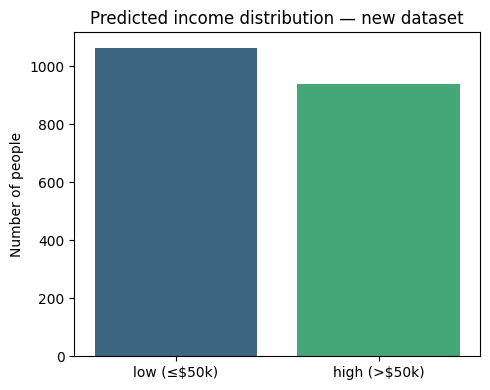

In [112]:
n_high = sum(new_predictions == 1)
n_low  = sum(new_predictions == 0)
n_total = len(new_predictions)

print(f"Predicted HIGH income (>$50k) : {n_high} ({n_high/n_total*100:.1f}%)")
print(f"Predicted LOW income (≤$50k)  : {n_low}  ({n_low/n_total*100:.1f}%)")
print(f"Total                          : {n_total}")

plt.figure(figsize=(5, 4))
sns.barplot(x=["low (≤$50k)", "high (>$50k)"], y=[n_low, n_high], palette="viridis")
plt.title("Predicted income distribution — new dataset")
plt.ylabel("Number of people")
plt.tight_layout()
plt.show()

## Can accuracy be measured on the new data?

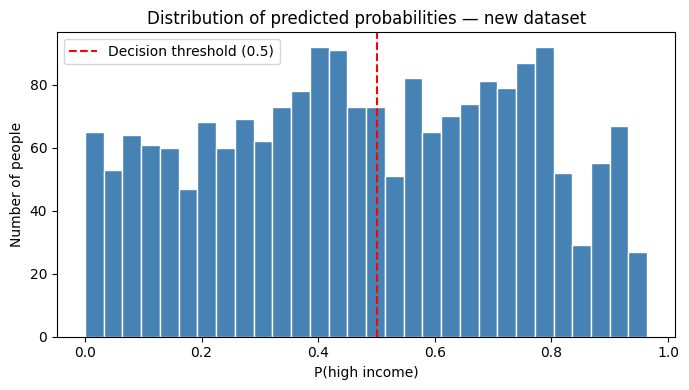

Mean predicted probability  : 0.479
Median                       : 0.478
% predictions above 0.7     : 25.2%  (confident high)
% predictions below 0.3     : 28.3%  (confident low)
% predictions near threshold: 23.5%  (uncertain)


In [113]:
plt.figure(figsize=(7, 4))
plt.hist(new_probas, bins=30, color="steelblue", edgecolor="white")
plt.axvline(0.5, color="red", linestyle="--", label="Decision threshold (0.5)")
plt.title("Distribution of predicted probabilities — new dataset")
plt.xlabel("P(high income)")
plt.ylabel("Number of people")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean predicted probability  : {new_probas.mean():.3f}")
print(f"Median                       : {pd.Series(new_probas).median():.3f}")
print(f"% predictions above 0.7     : {(new_probas > 0.7).mean()*100:.1f}%  (confident high)")
print(f"% predictions below 0.3     : {(new_probas < 0.3).mean()*100:.1f}%  (confident low)")
print(f"% predictions near threshold: {((new_probas >= 0.4) & (new_probas <= 0.6)).mean()*100:.1f}%  (uncertain)")

## Gender fairness analysis

The fairness analysis should be interpreted carefully because `sex` is included as an input feature, and both `cat__sex_Female` and `cat__sex_Male` appear among the selected top-10 features. The large difference in high-income prediction rates between males and females is therefore a potential fairness concern and may partly reflect the model using gender-related information.

In [114]:
print("Number of people by sex in the test dataset:")
display(income_test_raw["sex"].value_counts())

results_test["sex"] = income_test_raw["sex"]

# Percentage of low and high predictions for each gender
fairness = results_test.groupby("sex")["predicted_income"].value_counts(normalize=True).unstack()

print("Predicted income distribution by sex:")
display(fairness.round(3))

# Actual number of predictions in each group
print("\nNumber of predictions by sex:")
display(results_test.groupby("sex")["predicted_income"].value_counts().unstack())

Number of people by sex in the test dataset:


sex
Male      1153
Female     847
Name: count, dtype: int64

Predicted income distribution by sex:


predicted_income,high,low
sex,,
Female,0.249,0.751
Male,0.630,0.370



Number of predictions by sex:


predicted_income,high,low
sex,,
Female,211,636
Male,726,427


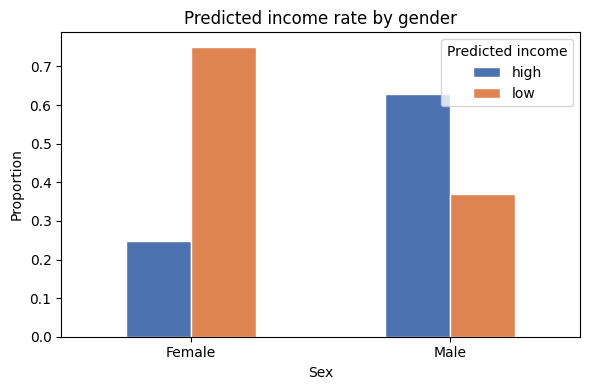

In [115]:
fairness_plot = results_test.groupby("sex")["predicted_income"].value_counts(normalize=True).unstack()

fairness_plot.plot(kind="bar", figsize=(6, 4), color=["#4C72B0", "#DD8452"], edgecolor="white")
plt.title("Predicted income rate by gender")
plt.xlabel("Sex")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Predicted income")
plt.tight_layout()
plt.show()

In [116]:
# Compare how often the model predicts high income for each gender
rate_male = (results_test[results_test["sex"] == "Male"]["predicted_income"] == "high").mean()
rate_female = (results_test[results_test["sex"] == "Female"]["predicted_income"] == "high").mean()

gap = abs(rate_male - rate_female)

print(f"High-income prediction rate for males  : {rate_male:.3f} ({rate_male*100:.1f}%)")
print(f"High-income prediction rate for females: {rate_female:.3f} ({rate_female*100:.1f}%)")
print(f"Difference between groups              : {gap:.3f}")

High-income prediction rate for males  : 0.630 (63.0%)
High-income prediction rate for females: 0.249 (24.9%)
Difference between groups              : 0.381


## Fill in predictions_template.csv

In [117]:
template_path = Path("predictions_template.csv")
template = pd.read_csv(template_path)

print("Template columns:", template.columns.tolist())
print("Template shape  :", template.shape)
display(template.head())

Template columns: ['id', 'income']
Template shape  : (2000, 2)


,id,income
0,1,low
1,2,high
2,3,high
3,4,low
4,5,high


In [118]:
template["income"] = new_labels

print(f"Filled {len(template)} predictions")
print("Distribution:")
print(pd.Series(new_labels).value_counts())
print()

display(template.head(10))

output_path = "predictions_template.csv"
template.to_csv(output_path, index=False)

print(f"\nSaved to {output_path}")

pd.read_csv("predictions_template.csv").head(10)

Filled 2000 predictions
Distribution:
low     1063
high     937
Name: count, dtype: int64



,id,income
0,1,low
1,2,high
2,3,high
3,4,low
4,5,high
5,6,high
6,7,low
7,8,high
8,9,low
9,10,low



Saved to predictions_template.csv


,id,income
0,1,low
1,2,high
2,3,high
3,4,low
4,5,high
5,6,high
6,7,low
7,8,high
8,9,low
9,10,low
